# CreditScope Stage 2: exploratory data analysis

This notebook presents reproducible, descriptive analysis of official UCI dataset 144. It trains no model, creates no train/test split, and treats the target as good/bad credit risk—not observed default.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

from creditscope.analysis import build_analysis_dataset
from creditscope.eda import generate_stage2_artifacts

project_root = Path.cwd()
data = build_analysis_dataset()
result = generate_stage2_artifacts(project_root, data=data)
result

{'rows': 1000,
 'candidate_features': 20,
 'figures_created': 10,
 'raw_snapshot_unchanged': True,
 'model_trained': False,
 'train_test_split_created': False}

## Dataset and target checks

In [2]:
pd.read_csv(project_root / 'reports' / 'dataset_overview.csv')

,metric,value
0,observations,1000
1,candidate_features,20
2,source_target_columns,1
3,analysis_binary_target_columns,1
4,missing_cells,0
5,duplicate_rows_including_targets,0


In [3]:
pd.read_csv(project_root / 'reports' / 'target_summary.csv')

,credit_risk_class,meaning,bad_credit_risk,count,percentage
0,1,good credit risk,0,700,0.7
1,2,bad credit risk,1,300,0.3


The 700/300 distribution is moderately imbalanced. Accuracy alone will be insufficient later because predicting every record as good credit risk would score 70%, and UCI's documented error costs are asymmetric.

## Numerical and categorical summaries

In [4]:
pd.read_csv(project_root / 'reports' / 'numerical_summary.csv')

,feature,count,mean,std,min,q25,median,q75,max
0,duration_months,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0
1,credit_amount,1000.0,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
2,installment_rate_percent,1000.0,2.973,1.118715,1.0,2.0,3.0,4.00,4.0
3,residence_duration,1000.0,2.845,1.103718,1.0,2.0,3.0,4.00,4.0
4,age_years,1000.0,35.546,11.375469,19.0,27.0,33.0,42.00,75.0
5,existing_credits_count,1000.0,1.407,0.577654,1.0,1.0,1.0,2.00,4.0
6,dependents_count,1000.0,1.155,0.362086,1.0,1.0,1.0,1.00,2.0


In [5]:
pd.read_csv(project_root / 'reports' / 'categorical_cardinality.csv')

,feature,documented_cardinality,observed_cardinality,minimum_observed_category_count
0,checking_account_status,4,4,63
1,credit_history,5,5,40
2,purpose,11,10,9
3,savings_account_status,5,5,48
4,employment_duration,5,5,62
5,personal_status_sex,5,4,50
6,other_debtors_guarantors,3,3,41
7,property,4,4,154
8,other_installment_plans,3,3,47
9,housing,3,3,108


In [6]:
pd.read_csv(project_root / 'reports' / 'rare_categories.csv')

,feature,category_code,category_meaning,count,percentage,observed
0,purpose,A44,domestic appliances,12,0.012,True
1,purpose,A48,retraining,9,0.009,True
2,purpose,A410,others,12,0.012,True


Rare-category flags use a predeclared threshold below 2% of records. They are descriptive flags only; no categories were removed or combined.

## Focused figures

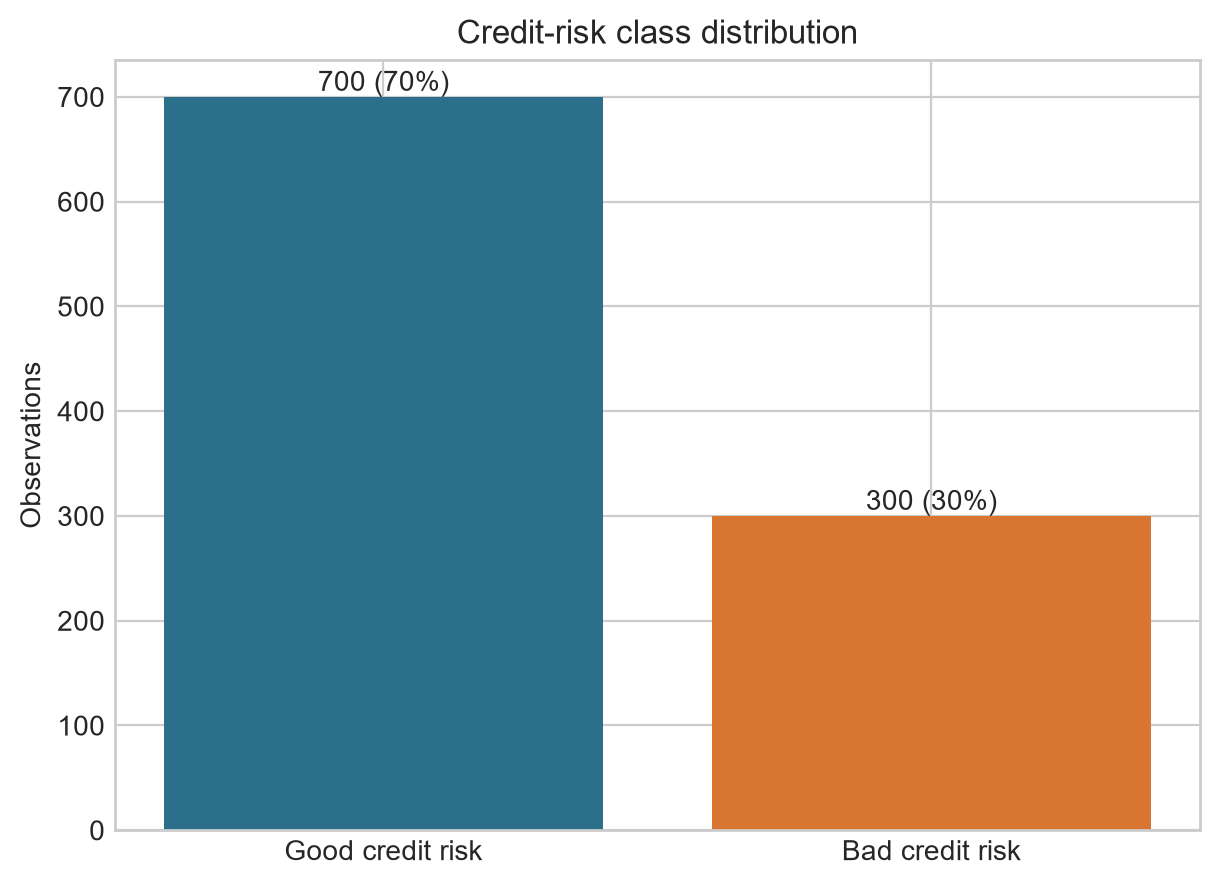

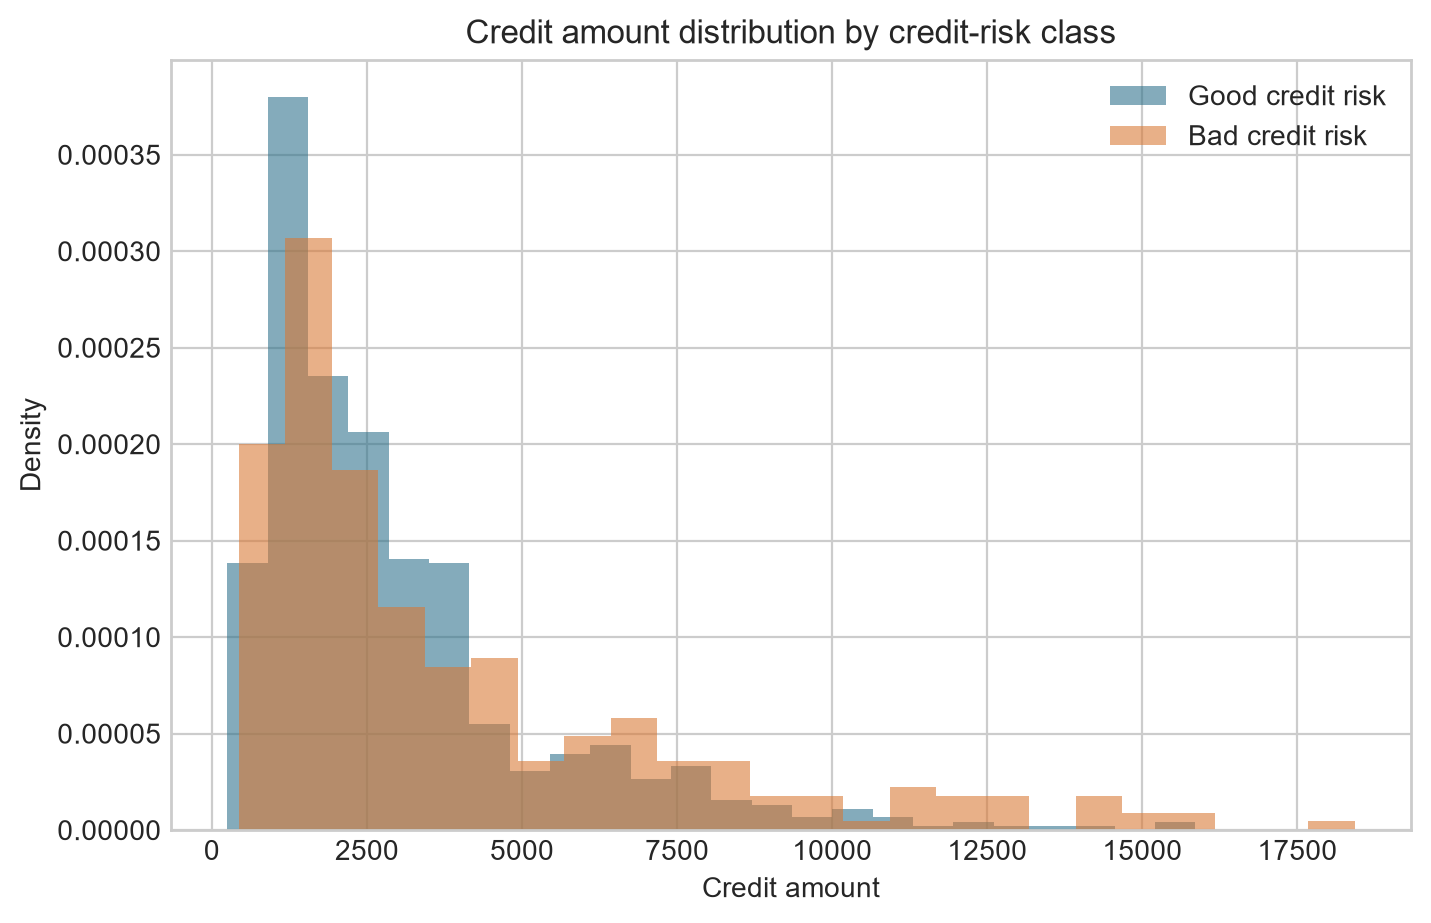

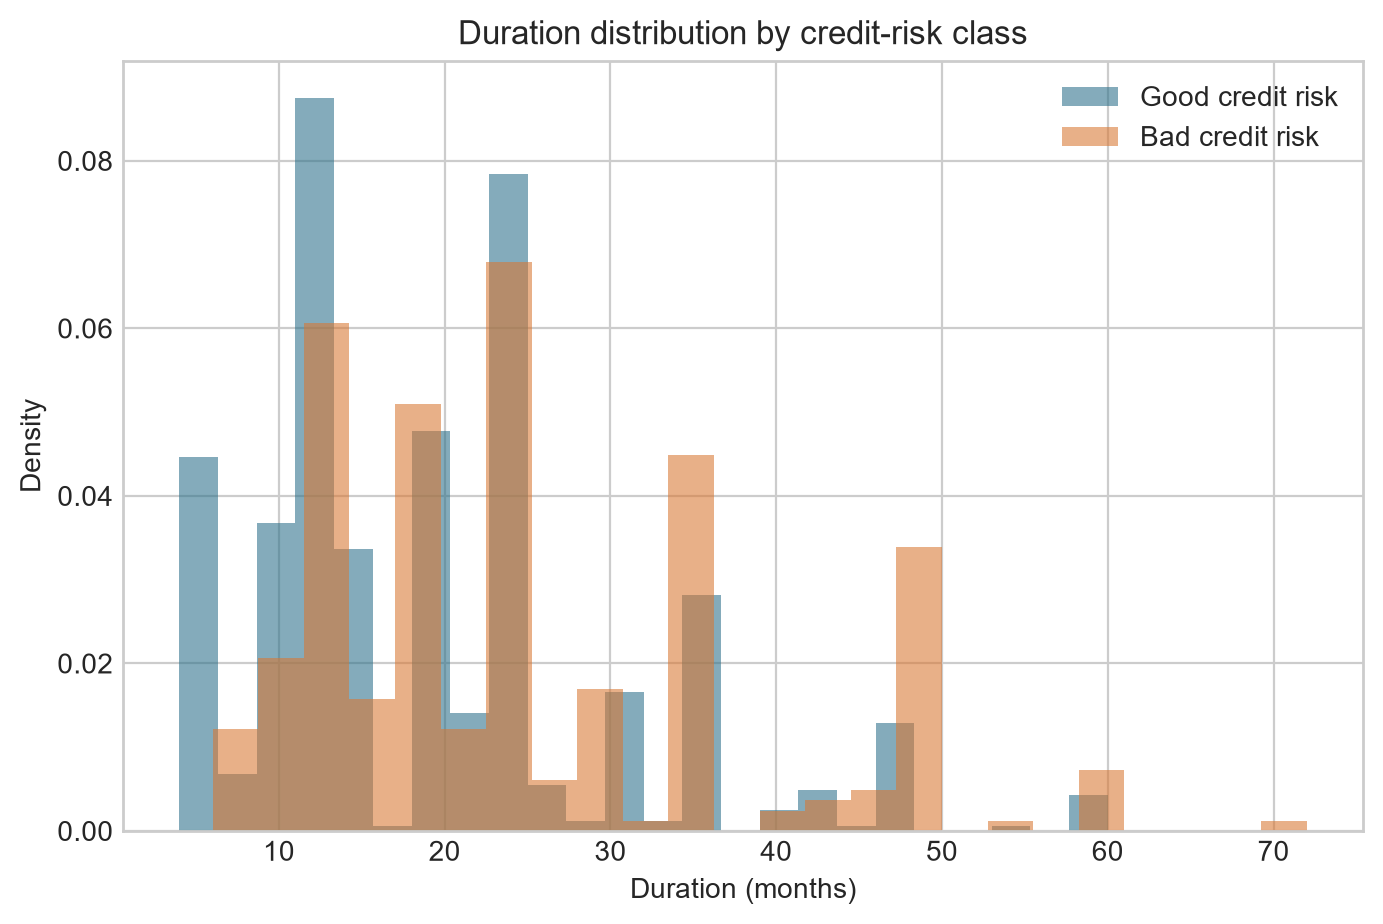

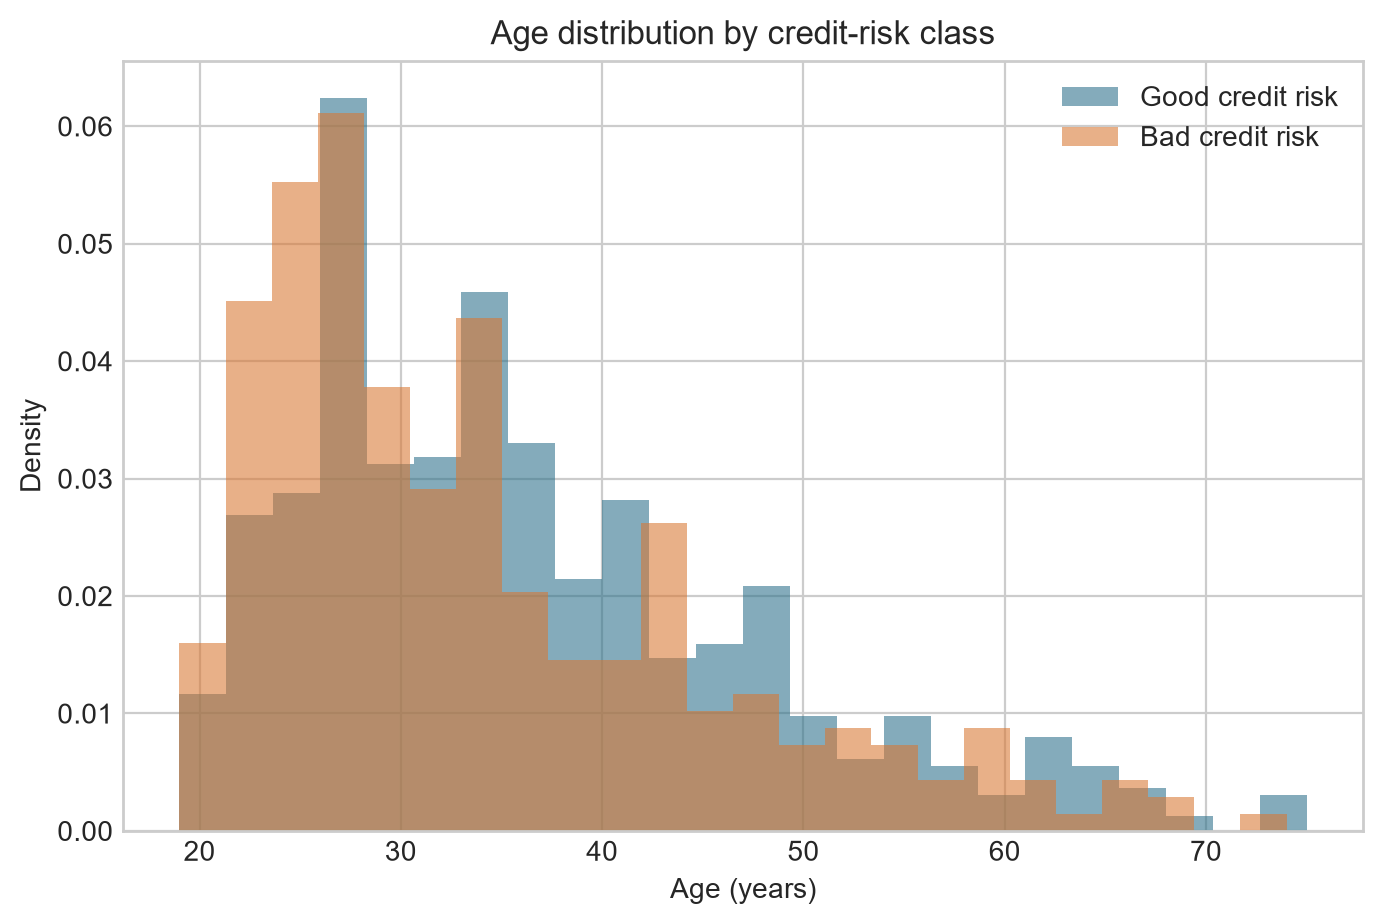

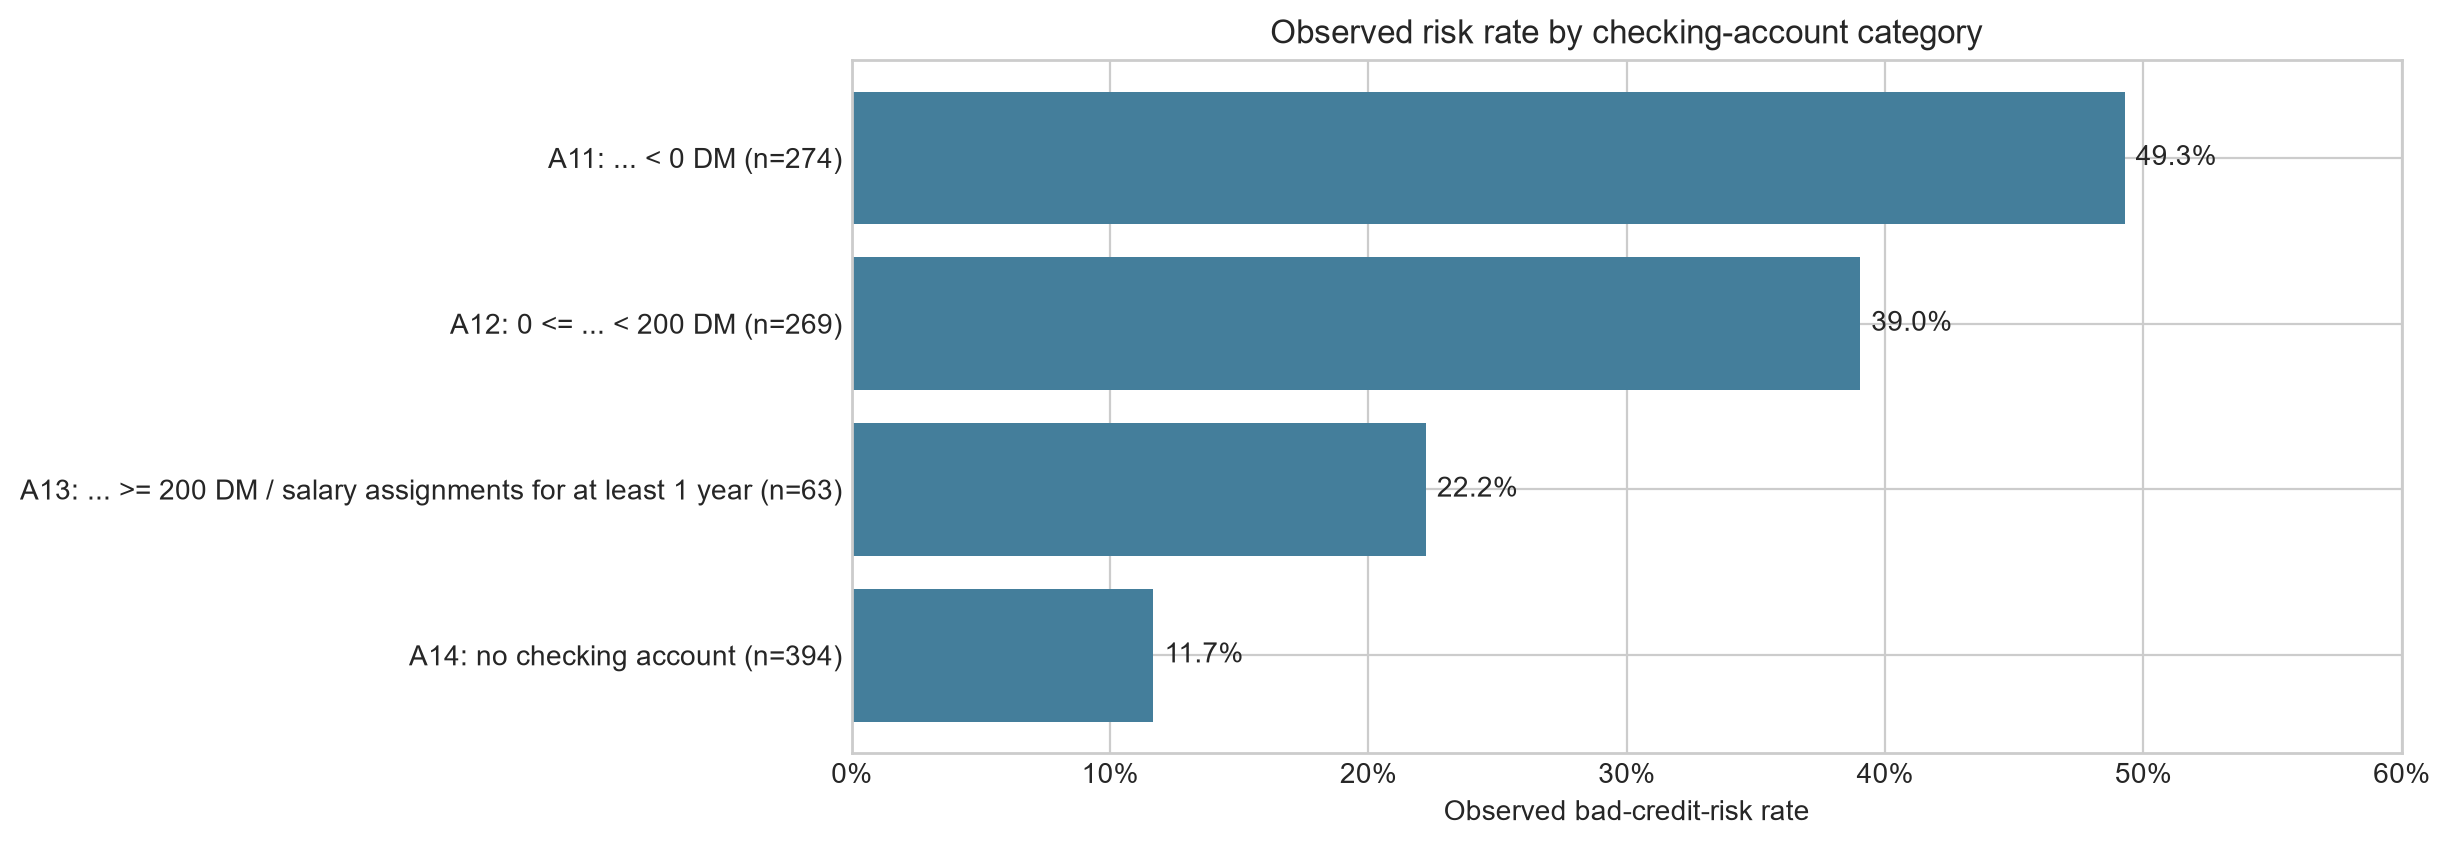

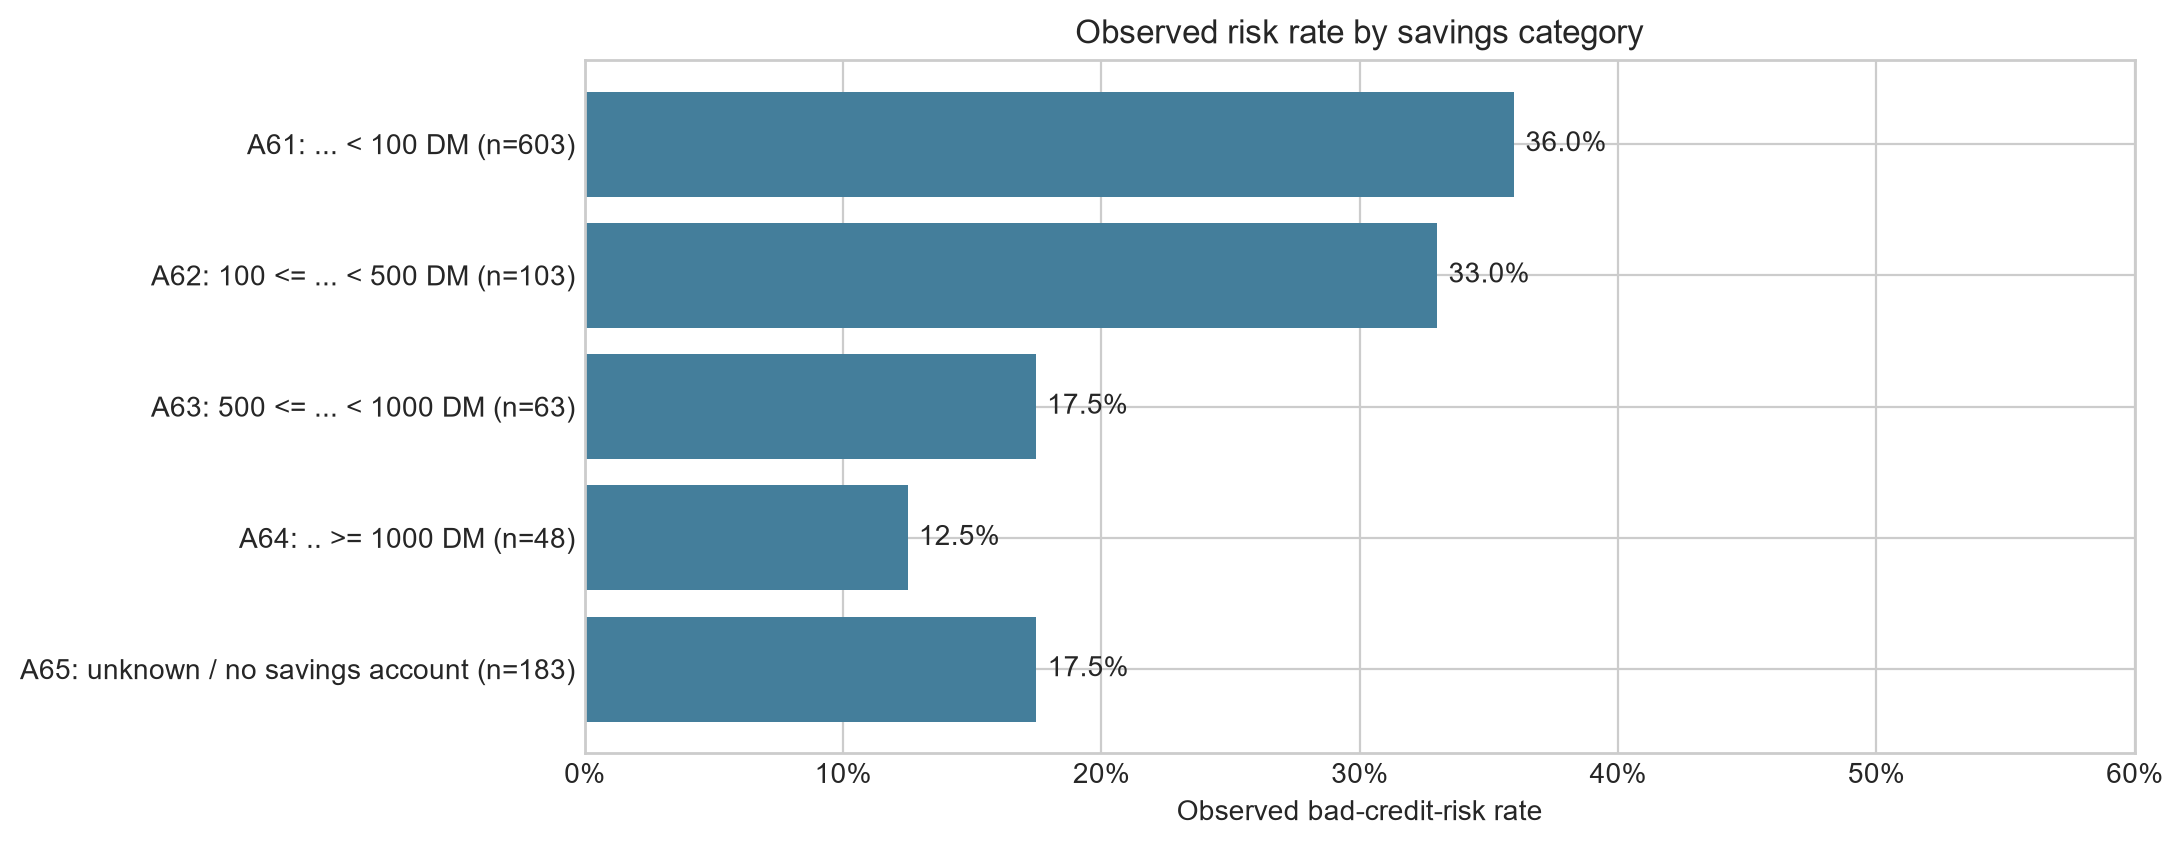

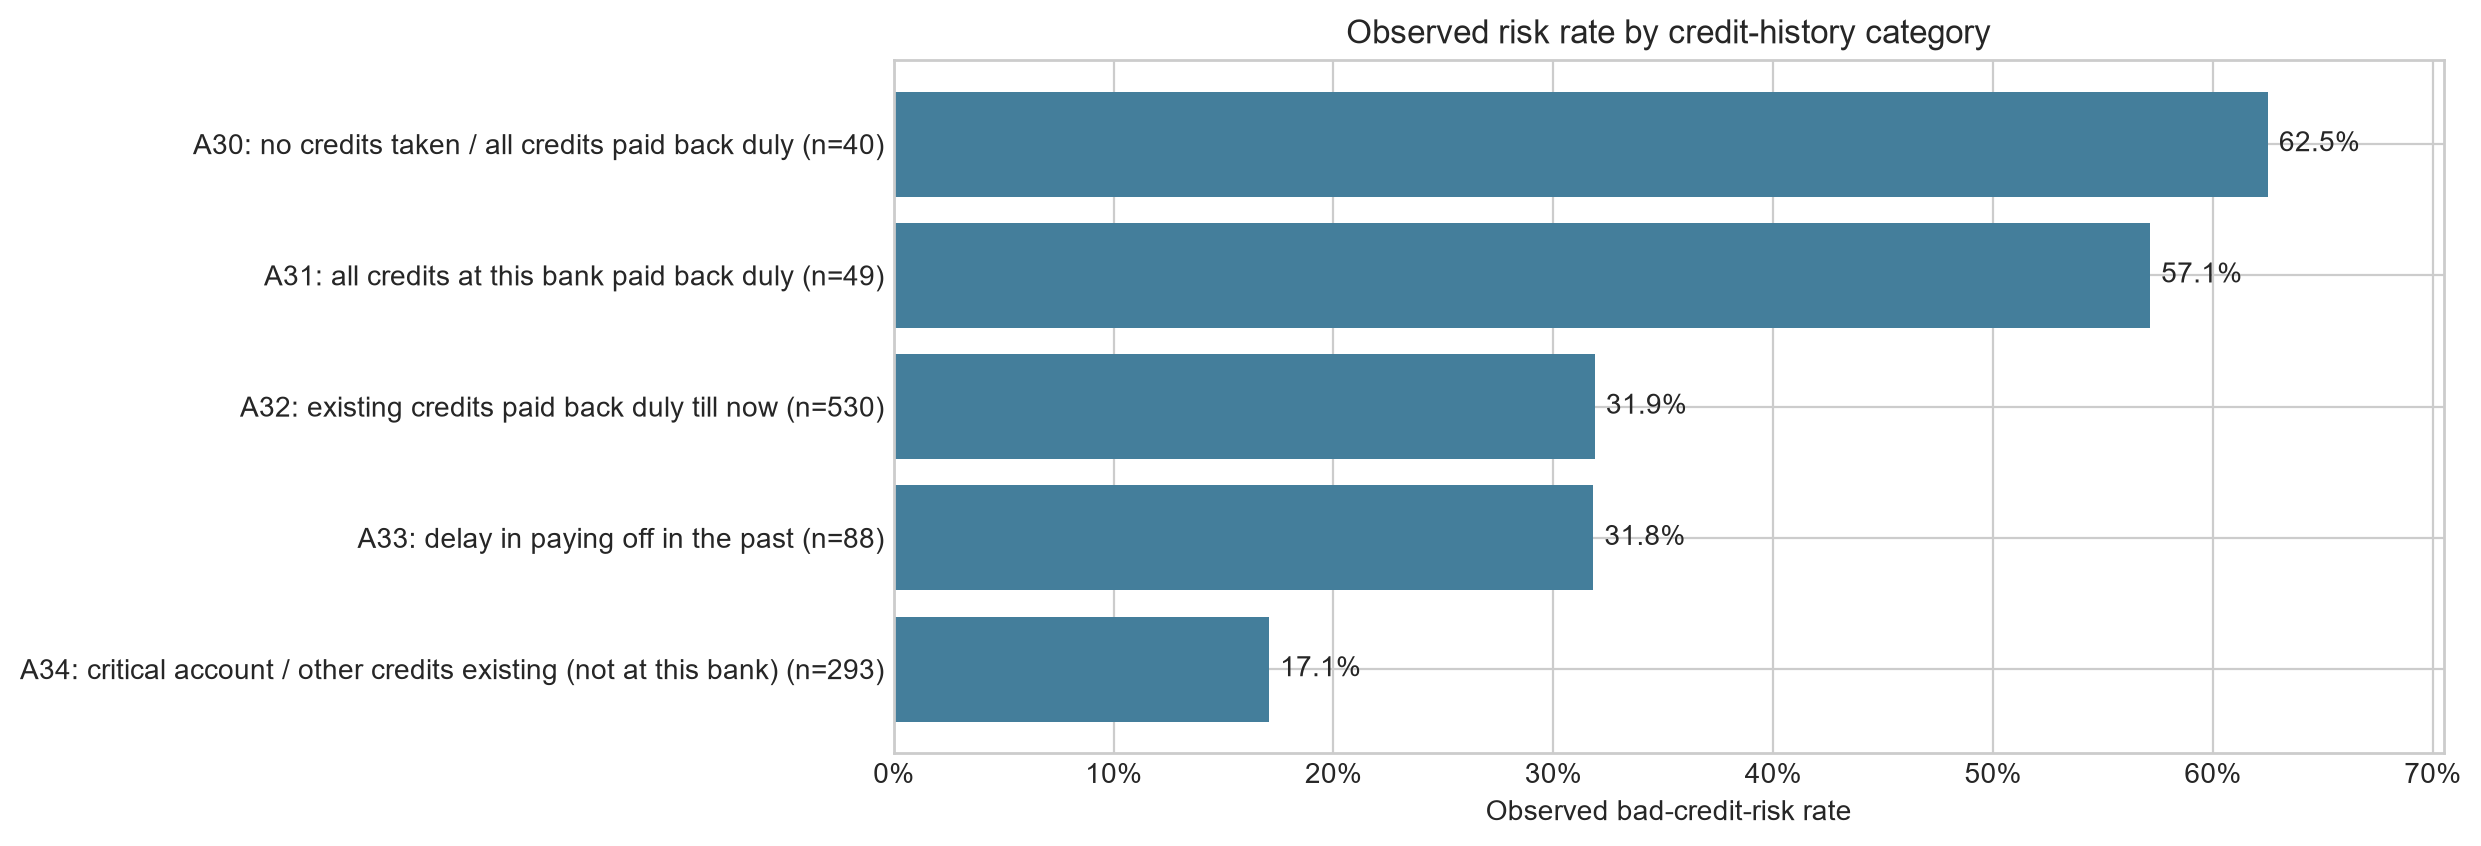

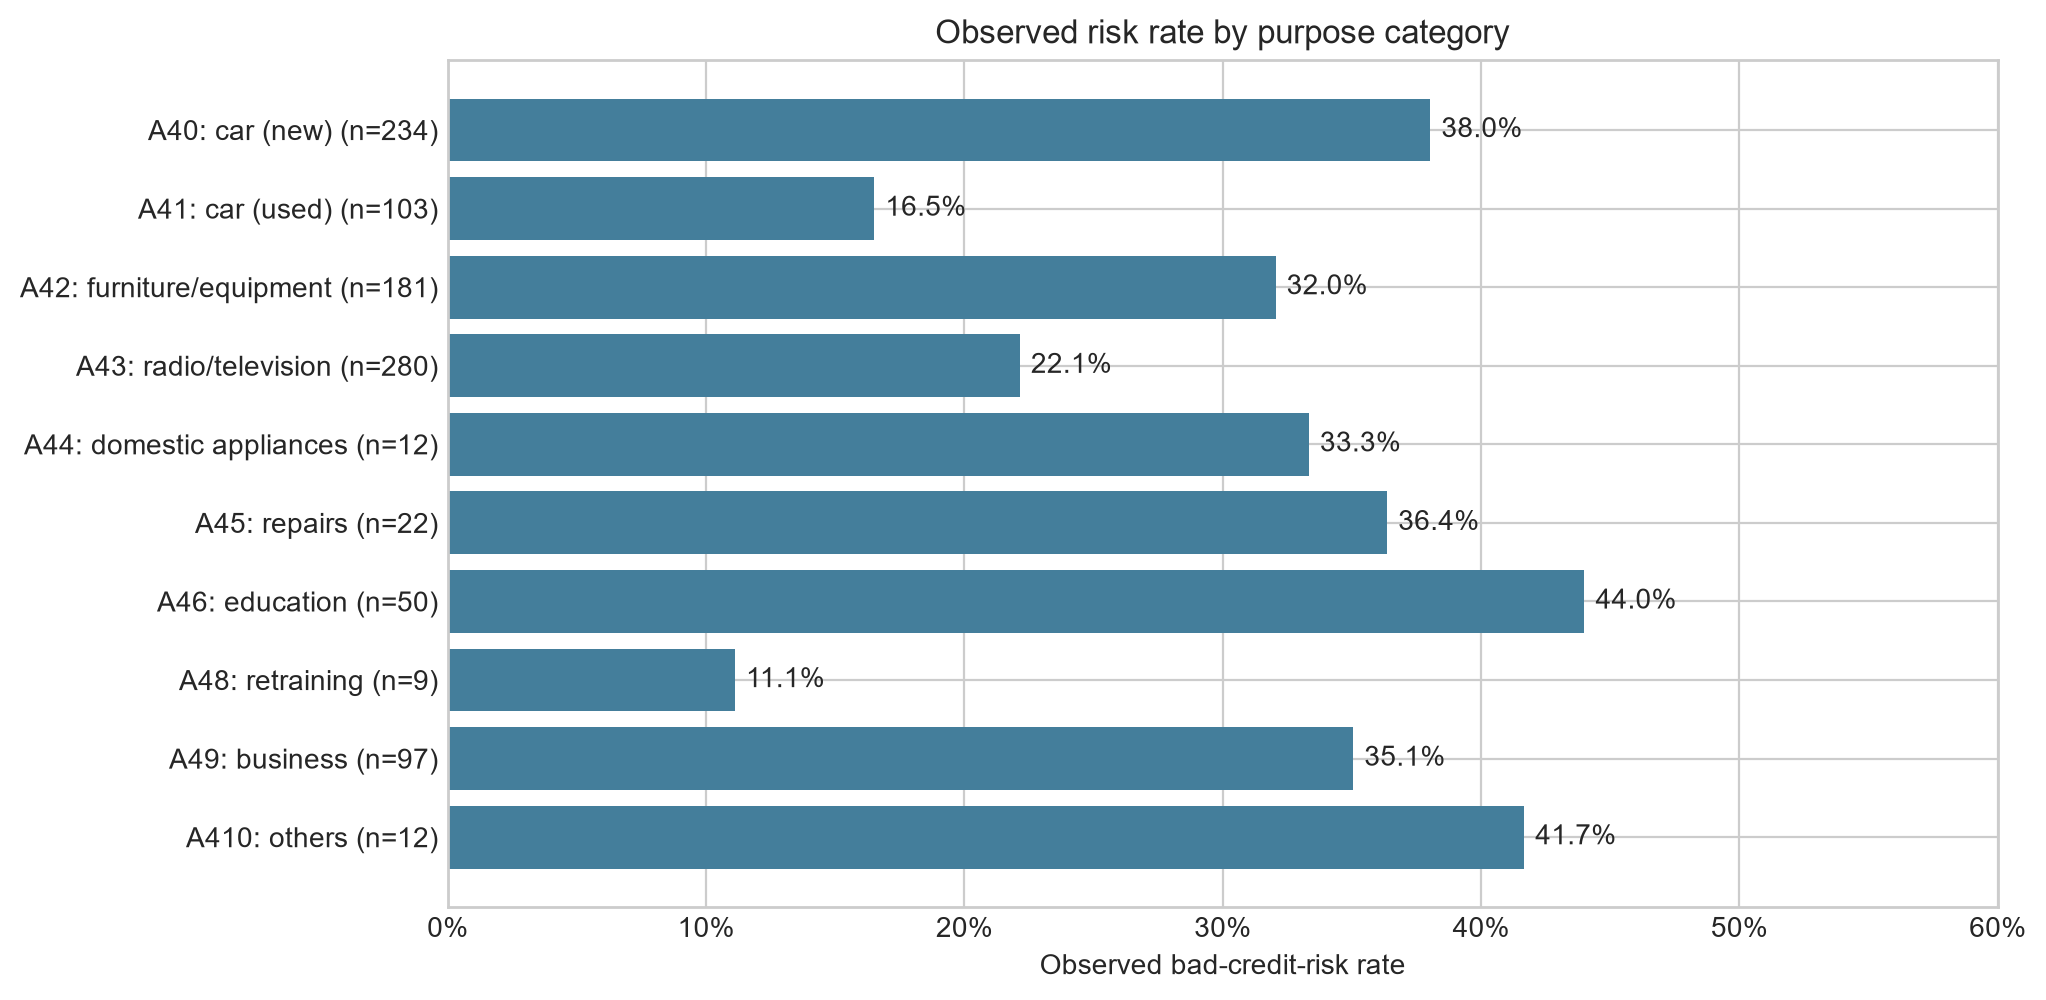

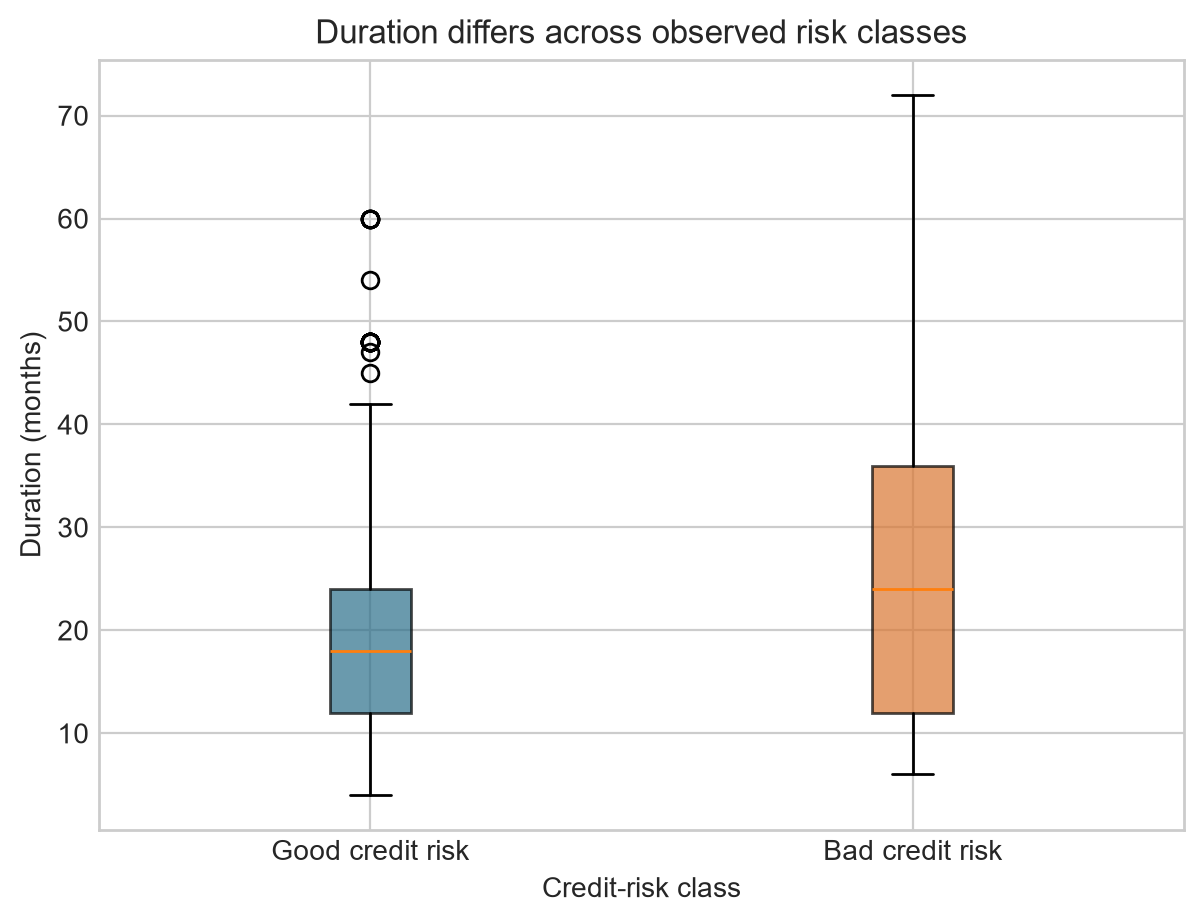

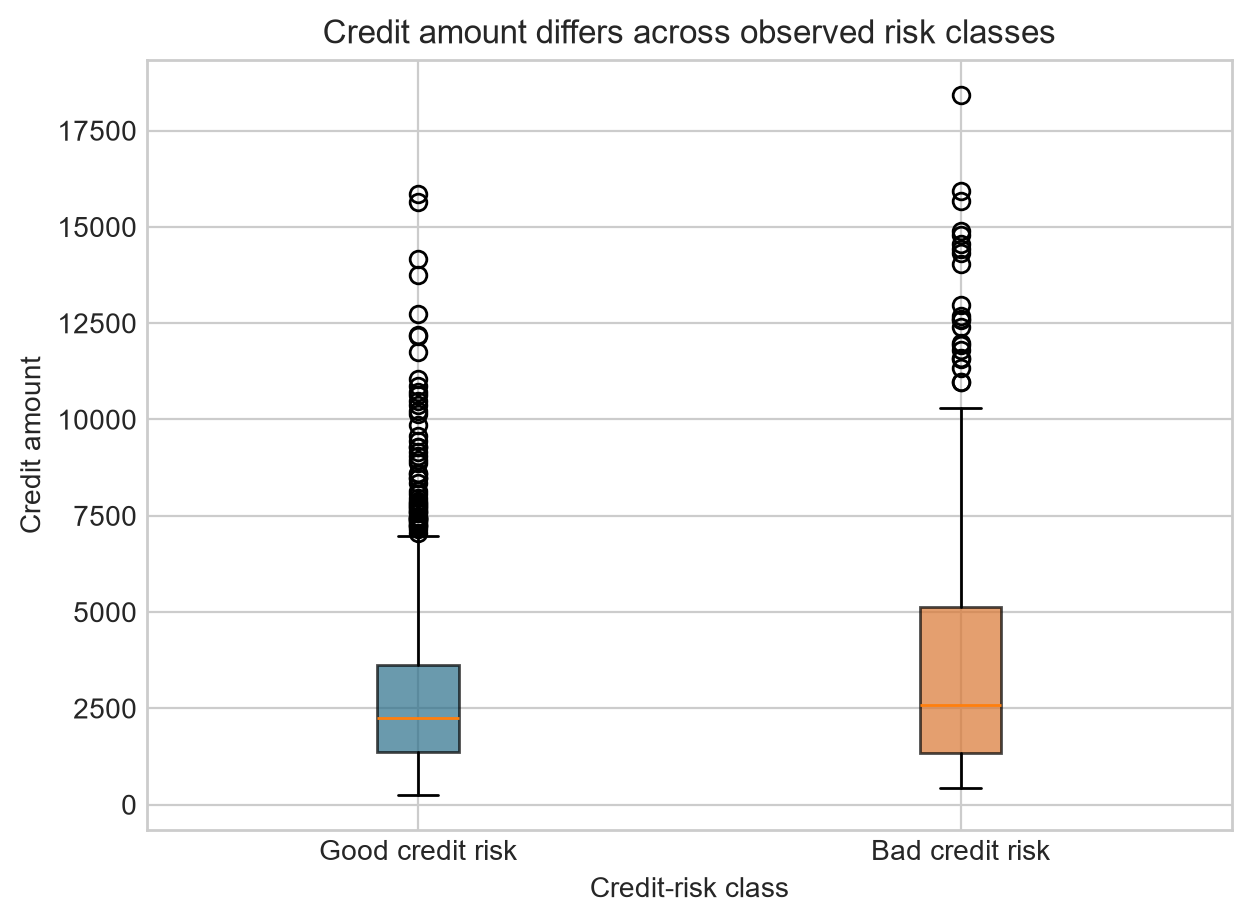

In [7]:
for figure_path in sorted((project_root / 'reports' / 'figures').glob('*.png')):
    display(Image(filename=str(figure_path)))

## Interpretation boundary

Observed rates differ across several categories, and duration and credit-amount distributions differ across credit-risk classes. These are sample associations, not causal effects. Small category sizes can produce unstable rates. Sensitive-feature, proxy, timing, preprocessing, validation, and cost-sensitive evaluation decisions remain open for Stage 3.